In [1]:
# load in necessary libraries
import os
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt

In [7]:
rivers = gpd.read_file(here("my-data/amzrivnet_v/amzrivnet_v.shp"))

<Axes: >

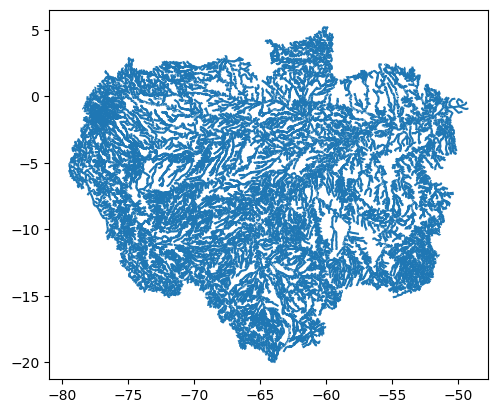

In [8]:
rivers.plot()

In [39]:
rivers_2 = gpd.read_file(here("my-data/brazil-water/brazil_water.shp"))

<Axes: >

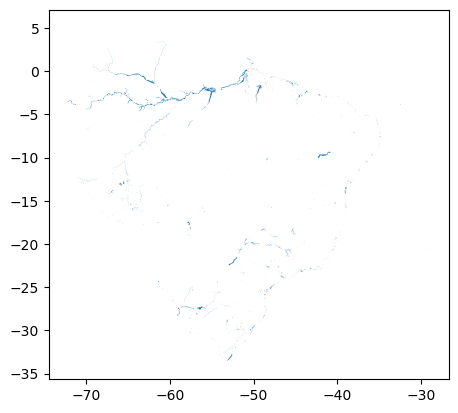

In [4]:
rivers_2.plot()

dataset source: 10.3334/ORNLDAAC/1086 (doi)


brazil waterways: https://data.humdata.org/dataset/hotosm_bra_waterways

In [5]:
rivers_2.head()

,NATURAL,NAME,geometry
0,water,None,"POLYGON ((-72.25565 -3.53243, -72.25102 -3.529..."
1,water,None,"POLYGON ((-71.86735 -3.33469, -71.85396 -3.327..."
2,water,None,"POLYGON ((-71.73747 -3.59353, -71.73764 -3.596..."
3,water,None,"POLYGON ((-71.37750 -3.83969, -71.37338 -3.837..."
4,water,None,"POLYGON ((-71.20086 -3.94519, -71.19846 -3.945..."


In [24]:
# convert to line instead of polygons
rivers_2['geometry'] = rivers_2.boundary

In [26]:
rivers_2['NATURAL'].unique()

array(['water', 'shoreline'], dtype=object)

In [28]:
rivers_2 = rivers_2[rivers_2['NATURAL'] != "shoreline"]

<Axes: >

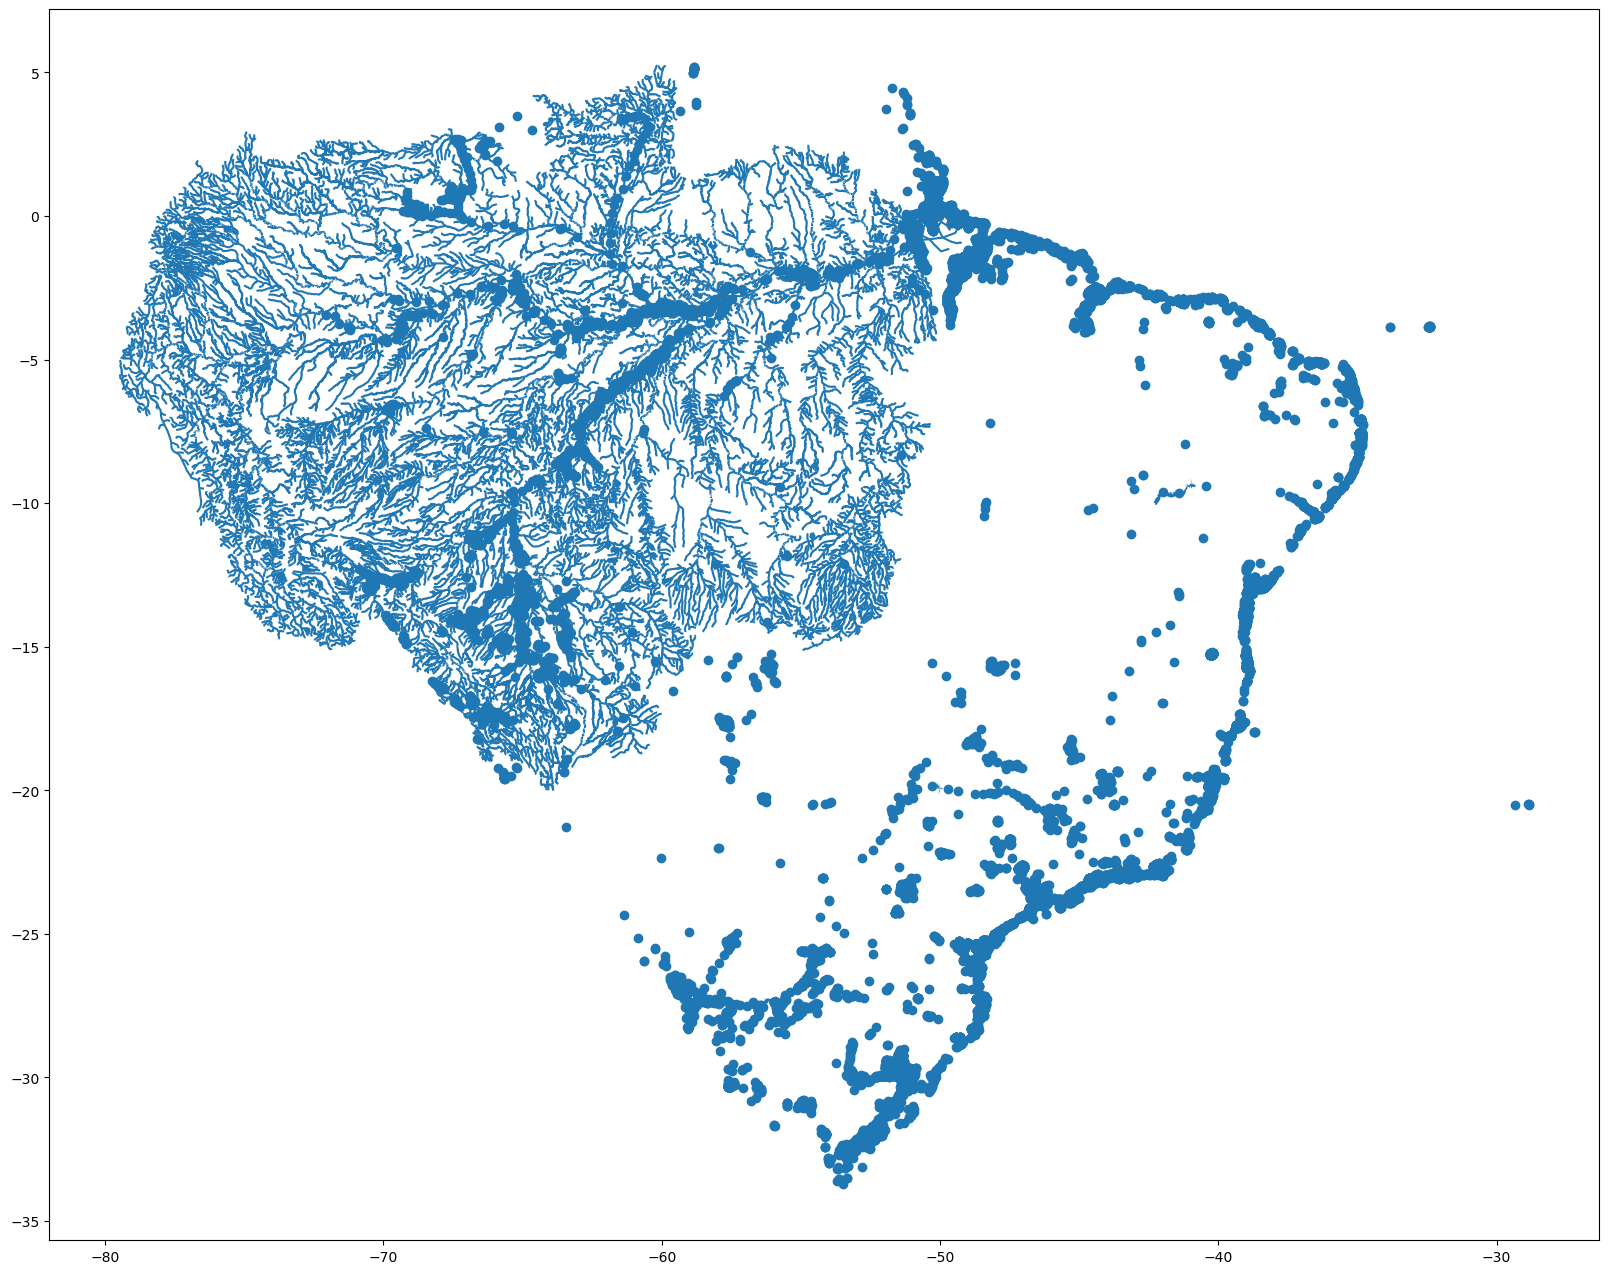

In [45]:
fig, ax = plt.subplots(figsize = (20, 20))
rivers.plot(ax=ax)
rivers_2.plot(ax=ax)

In [33]:
import geopandas as gpd
import momepy

# momepy requires a projected CRS (meters/feet, not degrees) for accurate calculations
if rivers_2.crs.is_geographic:
    gdf = rivers_2.to_crs(rivers_2.estimate_utm_crs())

# Extract centerlines
# Note: max_segment_length controls the resolution of the centerline
centerlines = momepy.Centerline(rivers_2, max_segment_length=2).geoms

# Create a new GeoDataFrame from the result
lines_gdf = gpd.GeoDataFrame(geometry=centerlines, crs=gdf.crs)


ModuleNotFoundError: No module named 'momepy'

In [42]:
import geopandas as gpd
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram
from shapely.validation import make_valid  # standard repair tool

def pure_shapely_centerline(poly, tolerance=0.5):
    # 1. Skip if empty
    if poly is None or poly.is_empty:
        return poly
    
    # 2. FIX INVALID GEOMETRIES
    if not poly.is_valid:
        poly = make_valid(poly) # Automatically fixes self-intersections and bowties
        # Alternative fix if using older shapely version: poly = poly.buffer(0)
    
    # Pass through lines immediately 
    if poly.geom_type in ['LineString', 'MultiLineString']:
        return poly
        
    # Safely get boundary for Polygon vs MultiPolygon
    boundary = poly.boundary if poly.geom_type == 'MultiPolygon' else poly.exterior
    
    # 3. Extract points along boundary
    # If your coordinates are degrees (lat/lon), step size 1 might be too large or too small.
    # We step by 1 unit here. 
    step = 1 if boundary.length > 5 else (boundary.length / 50)
    points = [boundary.interpolate(d) for d in range(0, int(boundary.length), int(step) if step >= 1 else 1)]
    
    if len(points) < 3:
        return poly.centroid
        
    # 4. Generate Voronoi diagram
    voronoi = voronoi_diagram(MultiPoint(points))
    
    # 5. Extract internal lines safely with a try/except safety net
    centerline_segments = []
    for line in voronoi.geoms:
        try:
            intersection = line.intersection(poly)
            if not intersection.is_empty:
                centerline_segments.append(intersection)
        except Exception:
            # If a specific line still causes a topology conflict, skip it instead of crashing
            continue
            
    # 6. Combine individual lines back together
    if centerline_segments:
        return gpd.GeoSeries(centerline_segments).unary_union
    else:
        return poly.centroid 

# Apply to your GeoDataFrame
rivers_2['geometry'] = rivers_2['geometry'].apply(pure_shapely_centerline)


AttributeError: 'GeometryCollection' object has no attribute 'exterior'

In [41]:
rivers_2.head()

,NATURAL,NAME,geometry
0,water,None,"POLYGON ((-72.25565 -3.53243, -72.25102 -3.529..."
1,water,None,"POLYGON ((-71.86735 -3.33469, -71.85396 -3.327..."
2,water,None,"POLYGON ((-71.73747 -3.59353, -71.73764 -3.596..."
3,water,None,"POLYGON ((-71.37750 -3.83969, -71.37338 -3.837..."
4,water,None,"POLYGON ((-71.20086 -3.94519, -71.19846 -3.945..."


In [43]:
import geopandas as gpd
from shapely.geometry import MultiPoint, Polygon, MultiPolygon
from shapely.ops import voronoi_diagram
from shapely.validation import make_valid

def pure_shapely_centerline(poly, tolerance=0.5):
    # 1. Skip if empty
    if poly is None or poly.is_empty:
        return poly
    
    # 2. Repair invalid geometries safely
    if not poly.is_valid:
        poly = make_valid(poly)
        
    # If make_valid turned it into a GeometryCollection, extract ONLY the polygon parts
    if poly.geom_type == 'GeometryCollection':
        polygons = [g for g in poly.geoms if g.geom_type in ['Polygon', 'MultiPolygon']]
        if not polygons:
            return poly.centroid  # Fallback if no polygons remain
        # Combine valid polygon pieces back together
        poly = gpd.GeoSeries(polygons).unary_union

    # 3. Handle line features immediately if they bypass or result from the step above
    if poly.geom_type in ['LineString', 'MultiLineString']:
        return poly
        
    # 4. Extract boundary points safely depending on geometry type
    if poly.geom_type == 'MultiPolygon':
        boundary = poly.boundary
    elif poly.geom_type == 'Polygon':
        boundary = poly.exterior
    else:
        return poly.centroid # Catch-all fallback

    # 5. Build step interval for sampling points along the boundary
    step = 1 if boundary.length > 5 else (boundary.length / 50)
    points = [boundary.interpolate(d) for d in range(0, int(boundary.length), int(step) if step >= 1 else 1)]
    
    if len(points) < 3:
        return poly.centroid
        
    # 6. Generate Voronoi diagram
    voronoi = voronoi_diagram(MultiPoint(points))
    
    # 7. Retain only the internal centerline vectors
    centerline_segments = []
    for line in voronoi.geoms:
        try:
            intersection = line.intersection(poly)
            if not intersection.is_empty:
                centerline_segments.append(intersection)
        except Exception:
            continue
            
    # 8. Unify individual lines into a clean backbone network
    if centerline_segments:
        return gpd.GeoSeries(centerline_segments).unary_union
    else:
        return poly.centroid 

# Apply safely to your GeoDataFrame
rivers_2['geometry'] = rivers_2['geometry'].apply(pure_shapely_centerline)


<Axes: >

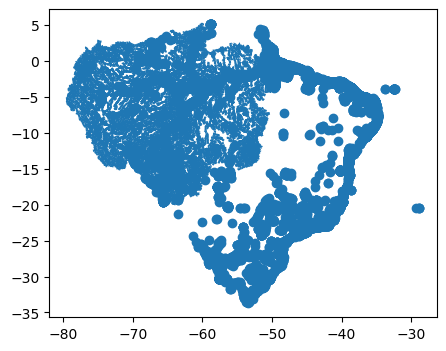

In [44]:
fig, ax = plt.subplots(figsize = (8, 4))
rivers.plot(ax=ax)
rivers_2.plot(ax=ax)

<Axes: >

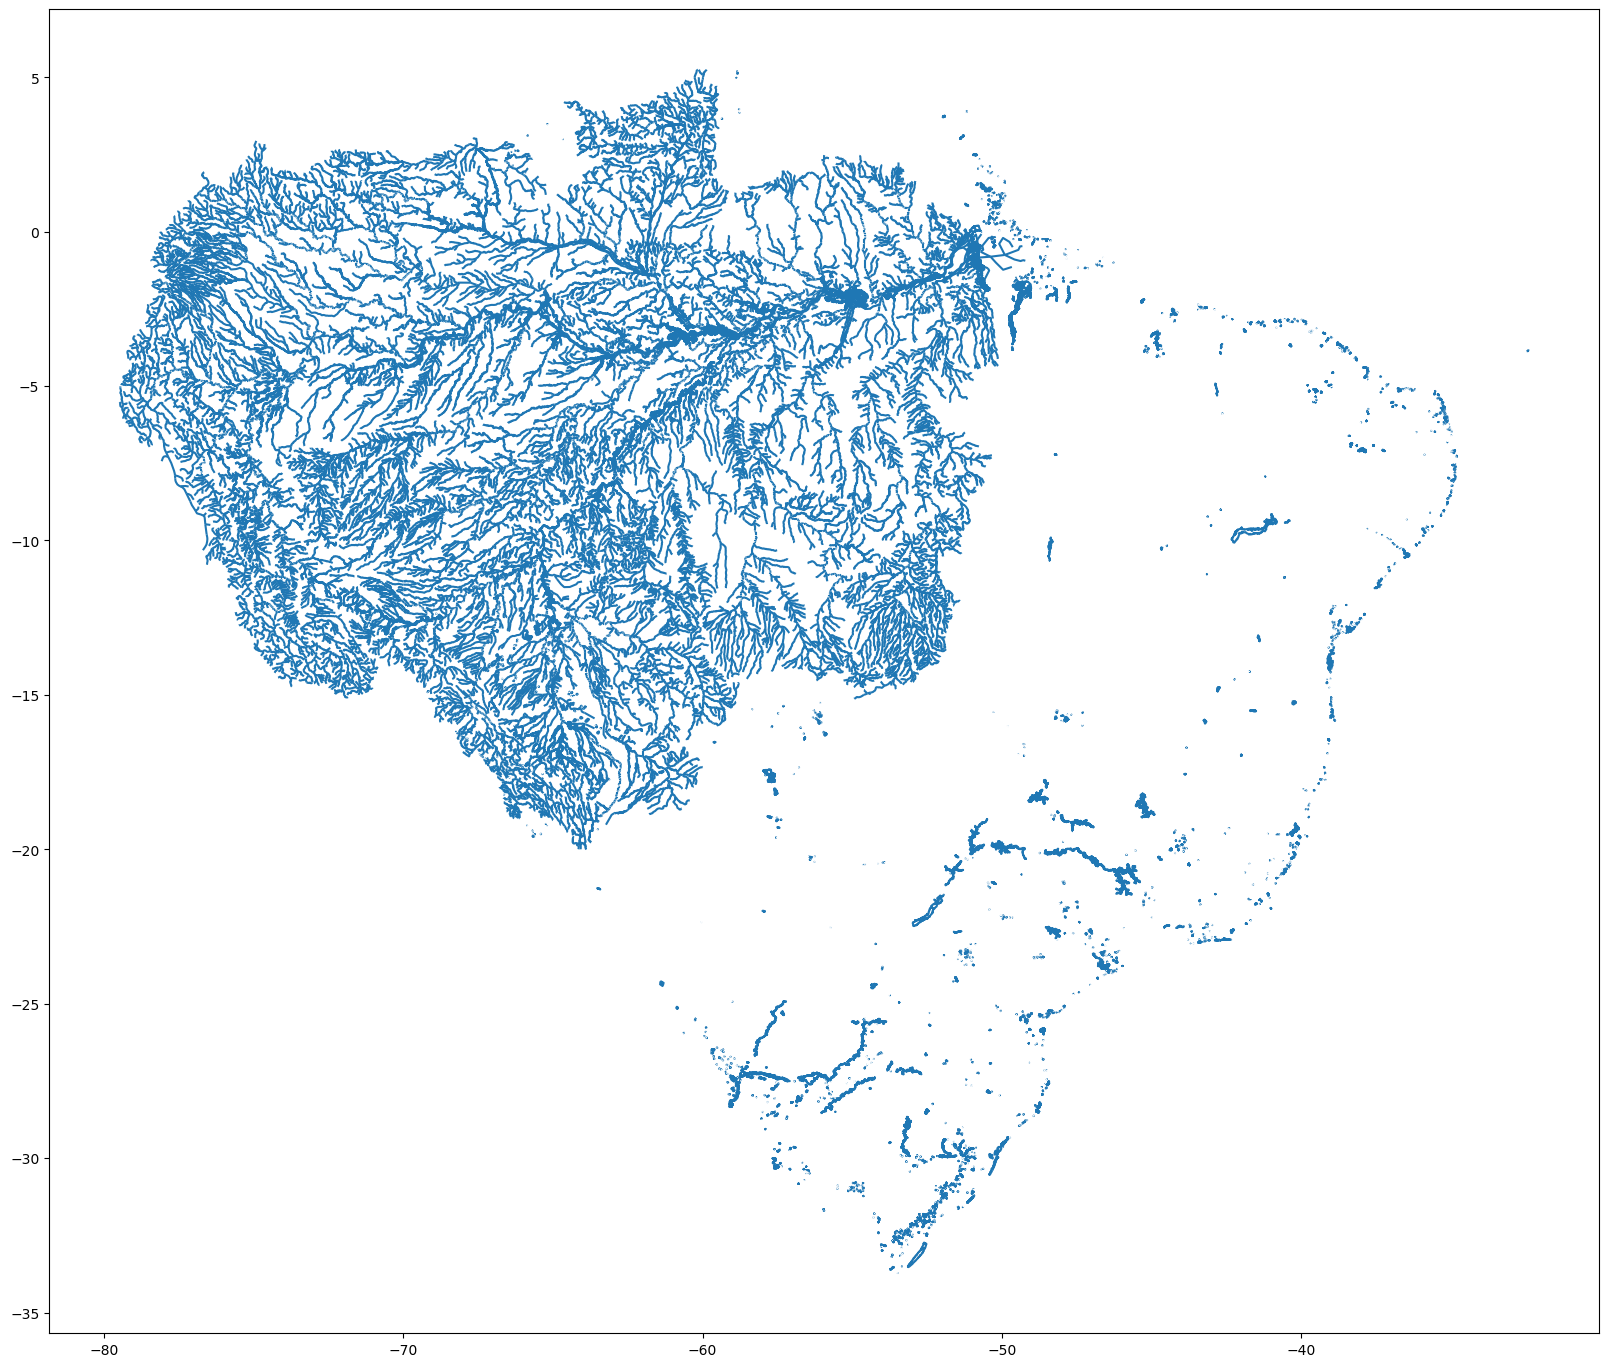

In [48]:
# final pipeline to save river geos of amazon and brazil (keeping polygon boundaries)
rivers = gpd.read_file(here("my-data/amzrivnet_v/amzrivnet_v.shp"))
rivers_2 = gpd.read_file(here("my-data/brazil-water/brazil_water.shp")).to_crs(rivers.crs)

# convert to line instead of polygons
rivers_2['geometry'] = rivers_2.boundary
rivers_2 = rivers_2[rivers_2['NATURAL'] != "shoreline"]

fig, ax = plt.subplots(figsize = (20, 20))
rivers.plot(ax=ax)
rivers_2.plot(ax=ax)

In [50]:
# combine river geos
combined_rivers = pd.concat([rivers, rivers_2], ignore_index=True)

In [51]:
# save combines rivers
combined_rivers.to_file(here("my-data/rivers.geojson"), driver="GeoJSON")

In [53]:
rivers = gpd.read_file(here("my-data/para/PA_1505502_RIOS_SIMPLES.shp"))

In [58]:
crs = rivers.crs

In [59]:
crs

In [60]:
print(crs)

None


In [61]:
rivers = rivers.set_crs("EPSG:31983")

<Axes: >

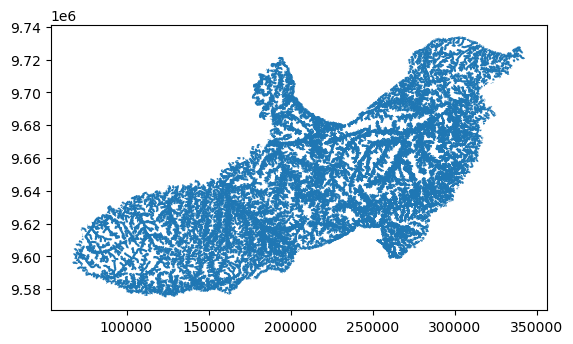

In [62]:
rivers.plot()